# Dataset 2 - EMD-Based Differential Entropy Features with 1D-CNN for Schizophrenia Detection

This notebook investigates schizophrenia detection on Dataset 2 using differential entropy features extracted from EEG signals after Empirical Mode Decomposition (EMD).

Each EEG segment is decomposed into IMFs, transformed into differential entropy descriptors, and used as input to a 1D Convolutional Neural Network.

In [2]:
import os
import zipfile
import numpy as np
import mne
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
from PyEMD import EMD
from scipy.signal import resample as sciresample
from scipy.stats import entropy
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, BatchNormalization, Flatten, Dense,LSTM, GRU
from tensorflow.keras.optimizers import Adam
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import KFold, cross_val_score

In [3]:
subsets = ["subset_1.zip", "subset_2.zip", "subset_3.zip"]
base_dir = "/content"

for subset_zip in subsets:
    with zipfile.ZipFile(os.path.join(base_dir, subset_zip), 'r') as zip_ref:
        zip_ref.extractall(base_dir)
        print(f"Contenu extrait pour {subset_zip}")

Contenu extrait pour subset_1.zip
Contenu extrait pour subset_2.zip
Contenu extrait pour subset_3.zip


In [4]:
def extract_category_from_gnr(gnr_path):
    try:
        with open(gnr_path, 'r') as f:
            for line in f:
                if line.startswith("category="):
                    cat_value = line.split("=")[1].strip()
                    if cat_value in ["Patient", "Control"]:
                        return cat_value
        return None
    except Exception as e:
        print(f"Erreur lecture {gnr_path}: {e}")
        return None

In [5]:
def unify_channels(signal, desired_channels=24):

    n_channels, n_times = signal.shape
    if n_channels < desired_channels:
        new_signal = np.zeros((desired_channels, n_times), dtype=signal.dtype)
        new_signal[:n_channels, :] = signal
        return new_signal
    elif n_channels > desired_channels:
        print(f"Tronquage de {n_channels} canaux à {desired_channels} canaux.")
        return signal[:desired_channels, :]
    else:
        return signal

In [6]:
def my_resample(signal, old_fs, target_fs=250):
    if abs(old_fs - target_fs) < 1e-9:
        return signal, old_fs

    n_channels, n_times_old = signal.shape
    n_times_new = int(n_times_old * (target_fs / old_fs))

    resampled = np.zeros((n_channels, n_times_new), dtype=signal.dtype)
    for ch in range(n_channels):
        resampled[ch, :] = sciresample(signal[ch, :], n_times_new)

    return resampled, target_fs

In [7]:
def segment_signal(signal, fs, window_size=10, overlap=0.5):

    window_samples = int(window_size * fs)
    step = int(window_samples * (1 - overlap))
    segments = []
    for start in range(0, signal.shape[1] - window_samples + 1, step):
        seg = signal[:, start:start+window_samples]
        segments.append(seg)
    return segments

In [8]:
def emd_channel(channel_data, max_imf=5):

    emd = EMD()
    imfs = emd(channel_data)
    if imfs.shape[0] > max_imf:
        imfs = imfs[:max_imf, :]
    return imfs

In [ ]:
def differential_entropy_gaussian(signal_1d, eps=1e-12):

    var = np.var(signal_1d) + eps  
    de = 0.5 * np.log(2 * np.pi * np.e * var)
    return de

In [ ]:
def emd_extract_features_segment(segment, max_imf=5):
    n_channels, n_times = segment.shape
    feats = []

    for ch in range(n_channels):
        imfs = emd_channel(segment[ch, :], max_imf=max_imf)
        n_imf_ch, _ = imfs.shape

        # On limite ou on pad pour avoir "max_imf" IMF
        padded_imfs = np.zeros((max_imf, n_times))
        padded_imfs[:n_imf_ch, :] = imfs

        for i_imf in range(max_imf):
            imf_1d = padded_imfs[i_imf, :]
            de = differential_entropy_gaussian(imf_1d)
            feats.append(de)

    return np.array(feats)

In [ ]:
def build_dataset(base_dir,
                  subsets=["subset_1","subset_2","subset_3"],
                  desired_channels=24,
                  target_fs=256,
                  window_size=10,
                  overlap=0.5,
                  max_imf=5,
                 ):

    X = []
    y = []

    subfolders = ["1","2","3"]

    for subset_name in subsets:
        subset_folder = os.path.join(base_dir, subset_name)
        if not os.path.isdir(subset_folder):
            print(f"{subset_folder} n'existe pas. Ignoré.")
            continue


        for subject in os.listdir(subset_folder):
            subject_dir = os.path.join(subset_folder, subject)
            if not os.path.isdir(subject_dir):
                continue

            category = None
            for sf in subfolders:
                sf_path = os.path.join(subject_dir, sf)
                if not os.path.isdir(sf_path):
                    continue

                gnr_file = None
                for f in os.listdir(sf_path):
                    if f.lower().endswith(".gnr"):
                        gnr_file = os.path.join(sf_path, f)
                        break
                if gnr_file:
                    cat = extract_category_from_gnr(gnr_file)
                    if cat in ["Patient","Control"]:
                        category = cat
                        break

            if category is None:
                continue

            label = 1 if category == "Patient" else 0

            for sf in subfolders:
                sf_path = os.path.join(subject_dir, sf)
                if not os.path.isdir(sf_path):
                    continue

                for f in os.listdir(sf_path):
                    if f.lower().endswith(".edf"):
                        edf_path = os.path.join(sf_path, f)
                        try:

                            raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
                            old_fs = raw.info['sfreq']
                            signal = raw.get_data()

                            # Unify :24 channels
                            signal_24 = unify_channels(signal, desired_channels)

                            # Resample :256 Hz
                            signal_rs, fs_rs = my_resample(signal_24, old_fs, target_fs)

                            segments = segment_signal(signal_rs, fs_rs,
                                                      window_size=window_size,
                                                      overlap=overlap)

                            # EMD + Entropie Diff
                            for seg in segments:
                                feats = emd_extract_features_segment(seg,
                                                                      max_imf=max_imf,
                                                                      )
                                X.append(feats)
                                y.append(label)

                        except Exception as e:
                            print(f"Erreur lecture {edf_path}: {e}")

    X = np.array(X)
    y = np.array(y)
    return X, y

In [ ]:
X, y = build_dataset(
    base_dir=base_dir,
    subsets=["subset_1","subset_2","subset_3"],
    desired_channels=24,
    target_fs=256,
    window_size=10,
    overlap=0.5,
    max_imf=5,

)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3805, 120)
y shape: (3805,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train set :", X_train.shape, y_train.shape)
print("Test set  :", X_test.shape, y_test.shape)

Train set : (3044, 120) (3044,)
Test set  : (761, 120) (761,)


In [ ]:
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [ ]:
def build_1d_cnn_model(input_shape):

    model = Sequential()

    model.add(Conv1D(filters=16, kernel_size=3, activation='relu', padding='same',
                     input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))

    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())

    model.add(Flatten())

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(64, activation='relu'))

    # Couche de sortie pour la classification binaire
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=1e-3),
        metrics=['accuracy']
    )

    return model

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)                   │ (None, 120, 16)             │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 120, 16)             │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_9 (MaxPooling1D)       │ (None, 60, 16)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_13 (Conv1D)                   │ (None, 60, 32)              │           1,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 60, 32)              │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_10 (MaxPooling1D)      │ (None, 30, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 30, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_14 (Conv1D)                   │ (None, 30, 64)              │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 30, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_11 (MaxPooling1D)      │ (None, 15, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_15 (Conv1D)                   │ (None, 15, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 15, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 1920)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │         245,888 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 287,713 (1.10 MB)

 Trainable params: 287,233 (1.10 MB)

 Non-trainable params: 480 (1.88 KB)

Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7440 - loss: 0.5497 - val_accuracy: 0.5320 - val_loss: 0.6805
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8406 - loss: 0.3834 - val_accuracy: 0.6174 - val_loss: 0.5763
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8586 - loss: 0.3224 - val_accuracy: 0.8424 - val_loss: 0.4087
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8526 - loss: 0.3237 - val_accuracy: 0.8374 - val_loss: 0.3833
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8507 - loss: 0.3412 - val_accuracy: 0.8752 - val_loss: 0.2658
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8963 - loss: 0.2405 - val_accuracy: 0.9130 - val_loss: 0.2127
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8989 - loss: 0.2378 - val_accuracy: 0.9195 - val_loss: 0.2103
Epoch 8/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9134 - loss: 0.2063 - val_accuracy: 0.

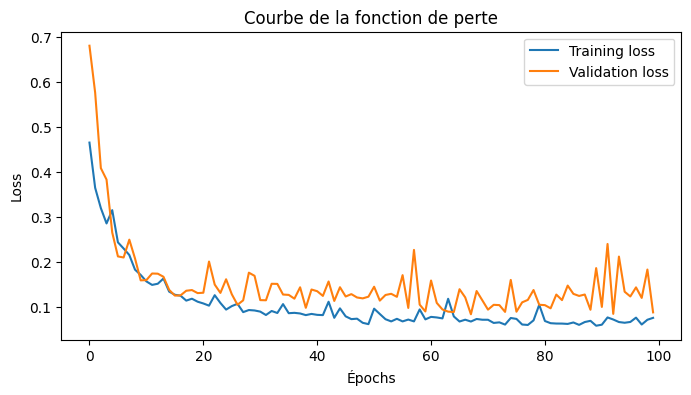

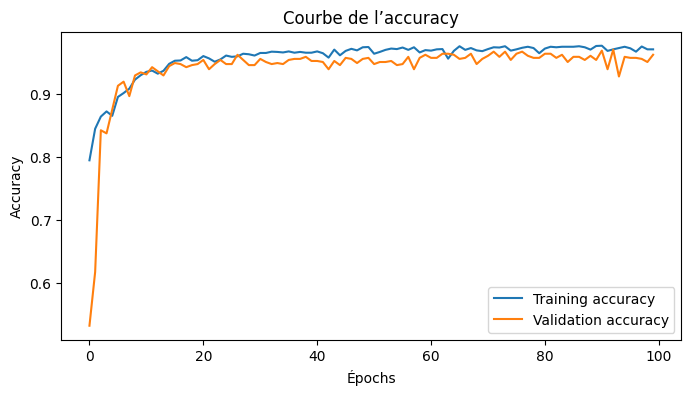

In [ ]:
model = build_1d_cnn_model(input_shape=(X_train_cnn.shape[1], 1))
model.summary()


history = model.fit(
    X_train_cnn, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    shuffle=True,
    verbose=1
)

loss, acc = model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Accuracy en test : {acc*100:.2f}%")

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Courbe de la fonction de perte')
plt.xlabel('Épochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Courbe de l’accuracy')
plt.xlabel('Épochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Matrice de confusion :
[[342  32]
 [  6 381]]


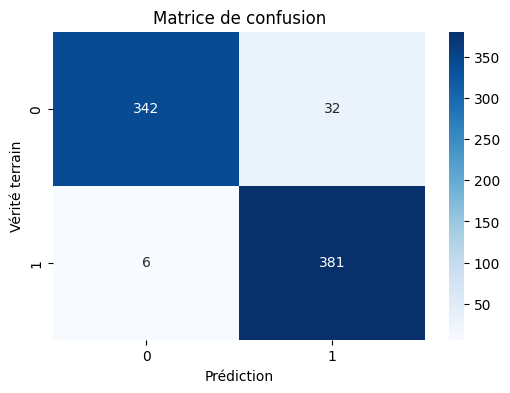

In [ ]:
y_pred_proba = model.predict(X_test_cnn)

y_pred = (y_pred_proba > 0.5).astype(int).ravel()

cm = confusion_matrix(y_test, y_pred)

print("Matrice de confusion :")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Vérité terrain")
plt.show()

In [ ]:
def cross_validation_5fold(X, y, epochs=10, batch_size=32):

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    accuracies = []
    fold_index = 1

    for train_index, val_index in kf.split(X, y):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        model = model = build_1d_cnn_model(input_shape=(X_train_cnn.shape[1], 1))


        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0  
        )

        loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
        accuracies.append(accuracy)

        print(f"Fold {fold_index} : validation accuracy = {accuracy:.4f}")
        fold_index += 1

    mean_acc = np.mean(accuracies)
    print(f"\nAccuracy moyenne sur 5 folds = {mean_acc:.4f}")
    return mean_acc

In [ ]:
mean_accuracy = cross_validation_5fold(
        X, y,
        epochs=80,
        batch_size=64
    )
print("Accuracy moyenne (5-fold) =", mean_accuracy)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 : validation accuracy = 0.9658
Fold 2 : validation accuracy = 0.9540
Fold 3 : validation accuracy = 0.9711
Fold 4 : validation accuracy = 0.9750
Fold 5 : validation accuracy = 0.9619

Accuracy moyenne sur 5 folds = 0.9656
Accuracy moyenne (5-fold) = 0.9655716180801391
